# Woche 7: Data Cleaning - Übung am eigenen Projekt

**Ziel dieser Übung:** Nachdem Sie die wichtigsten Aspekte des Data Cleanings am Airbnb-Beispiel kennengelernt haben, wenden Sie dieses Wissen Schritt für Schritt auf Ihren eigenen Datensatz an.

**Arbeitsweise:**
- Arbeiten Sie die Aufgaben nacheinander durch
- Nutzen Sie die Code-Zellen für Ihre Implementierung
- Orientieren Sie sich an den Beispielen aus dem Airbnb-Notebook
- Das bereinigte Dataset speichern Sie am Ende ab

---
## 1. Daten einlesen und Bibliotheken importieren

**Aufgabe:** Importieren Sie die notwendigen Bibliotheken und laden Sie Ihren Datensatz.

**Hinweise:**
- Importieren Sie: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`
- Setzen Sie einen Zufallsseed für Reproduzierbarkeit
- Laden Sie Ihren CSV-Datensatz mit `pd.read_csv()`

In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import functools

pd.set_option('display.max_columns', None)
print("Bibliotheken importiert")

Bibliotheken importiert


In [441]:
# Zufallsseed setzen
np.random.seed(1)

# Datensatz einlesen (NHANES 08/2021 - 08/2023, liegt als mehrere XPT-Dateien vor)

# Demographische Daten
dateipfad_demografic = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt"
# Dokumentation: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.htm
df_demo = pd.read_sas(dateipfad_demografic, format='xport')

# Körpermaße
dateipfad_body_measures = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.xpt"
# Dokumentation: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.htm
df_bm = pd.read_sas(dateipfad_body_measures, format='xport')

# Makronährstoffe und Kalorien
dateipfad_kcal = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DR1TOT_L.xpt"
# Dokumentation: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DR1TOT_L.htm#DR1TKCAL
# es gibt Daten über zwei Tage vor Erhebung, ich habe mich für den ersten entschieden
df_kcal = pd.read_sas(dateipfad_kcal, format='xport')

# Alkoholkonsum
dateipfad_alcohol = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/ALQ_L.xpt"
# Dokumentation: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/ALQ_L.htm
df_alc = pd.read_sas(dateipfad_alcohol, format='xport')

# Körperliche Aktivität
dateipfad_ph_act = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/PAQ_L.xpt"
# Dokumentation: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/PAQ_L.htm
df_ph_act = pd.read_sas(dateipfad_ph_act, format='xport')

# Schlaf
dateipfad_sleep = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/SLQ_L.xpt"
# Dokumentation: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/SLQ_L.htm
df_sleep = pd.read_sas(dateipfad_sleep, format='xport')

# Rauchen
dateipfad_smoke = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/SMQ_L.xpt"
# Dokumentation: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/SMQ_L.htm
df_smoke = pd.read_sas(dateipfad_smoke, format='xport')


# Überblick verschaffen um dann Tabellen zusammenzuführen
print("Demographie: ", df_demo.shape)
print(df_demo.head())
print()

print("Körpermaße: ", df_bm.shape)
print(df_bm.head())
print()

print("Makronährstoffe und Kalorien: ", df_kcal.shape)
print(df_kcal.head())
print()

print("Alkohol: ", df_alc.shape)
print(df_alc.head())
print()

print("Körperliche Aktivität: ", df_ph_act.shape)
print(df_ph_act.head())
print()

print("Schlaf: ", df_sleep.shape)
print(df_sleep.head())
print()

print("Rauchen: ", df_smoke.shape)
print(df_smoke.head())
print()


Demographie:  (11933, 27)
       SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  130378.0      12.0       2.0       1.0      43.0       NaN       5.0   
1  130379.0      12.0       2.0       1.0      66.0       NaN       3.0   
2  130380.0      12.0       2.0       2.0      44.0       NaN       2.0   
3  130381.0      12.0       2.0       2.0       5.0       NaN       5.0   
4  130382.0      12.0       2.0       1.0       2.0       NaN       3.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  DMQMILIZ  DMDBORN4  DMDYRUSR  DMDEDUC2  \
0       6.0       2.0       NaN       2.0       2.0       6.0       5.0   
1       3.0       2.0       NaN       2.0       1.0       NaN       5.0   
2       2.0       1.0       NaN       2.0       2.0       6.0       3.0   
3       7.0       1.0      71.0       NaN       1.0       NaN       NaN   
4       3.0       2.0      34.0       NaN       1.0       NaN       NaN   

   DMDMARTZ  RIDEXPRG  DMDHHSIZ  DMDHRGND  DMDHRAGZ  DMDHREDZ  DMDHRMAZ 

In [442]:
# Kopien erzeugen, in denen nur relevante Spalten berücksichtigt werden

df_clean_demo = df_demo[
    (df_demo["RIDSTATR"] == 2) & # --> Proband wurde befragt und untersucht
    (df_demo["RIDEXPRG"] != 1) & # Schwangere sollen nicht berücksichtigt werden
    (df_demo["RIDAGEYR"] >= 20) # es sollen nur Probanden ab einem Alter von 20 Jahren berücksichtigt werden
][["SEQN", "RIAGENDR", "RIDAGEYR", "DMDEDUC2", "INDFMPIR"]]

df_clean_bm = df_bm[["SEQN", "BMXBMI"]]

df_clean_kcal = df_kcal[["SEQN", "DR1TKCAL", "DR1TPROT", "DR1TCARB", "DR1TSUGR", "DR1TFIBE", "DR1TTFAT"]]

df_clean_alc = df_alc[["SEQN", "ALQ111", "ALQ121"]]

df_clean_ph_act = df_ph_act #hier brauchen wir alle Spalten

df_clean_sleep = df_sleep[["SEQN", "SLD012", "SLD013"]]

df_clean_smoke = df_smoke[["SEQN", "SMQ020", "SMQ040"]]


In [443]:
# Tabellen zusammenführen
dataframes = [
    df_clean_demo,
    df_clean_bm,
    df_clean_kcal,
    df_clean_alc,
    df_clean_ph_act,
    df_clean_sleep,
    df_clean_smoke
]

df_merge = functools.reduce(
    lambda left, right: pd.merge(left, right, on="SEQN", how="left"), # es sollen nur Zeilen aufgenommen werden,
    # die in der gefilterten Demographie-Tabelle enthalten sind
    dataframes
)
df_clean = df_merge.copy()

print(f"Geladen: {df_clean.shape[0]} Zeilen, {df_clean.shape[1]} Spalten")

Geladen: 6023 Zeilen, 25 Spalten


---
## 2. Ersten Überblick verschaffen

**Aufgabe:** Verschaffen Sie sich einen ersten Überblick über Ihren Datensatz.

**Was Sie prüfen sollten:**
- Wie viele Zeilen und Spalten hat der Datensatz?
- Welche Spalten gibt es und welche Datentypen haben sie?
- Wie sehen die ersten Zeilen aus?

In [444]:
# sprechendere Spaltennamen vergeben
df_clean = df_clean.rename(columns={
    "SEQN":     "id",
    "RIAGENDR": "gender",
    "RIDAGEYR": "age",
    "DMDEDUC2": "education_lvl",
    "INDFMPIR": "income",
    "BMXBMI":   "bmi",
    "DR1TKCAL": "kcal",
    "DR1TPROT": "protein",
    "DR1TCARB": "carbs",
    "DR1TSUGR": "sugar",
    "DR1TFIBE": "fiber",
    "DR1TTFAT": "fat",
    "ALQ111":    "alc_ever",
    "ALQ121":   "alcohol",
    "PAD790Q":  "mod_act_frq",
    "PAD790U":  "mod_act_scale",
    "PAD800":   "mod_act_min",
    "PAD810Q":  "int_act_frq", 
    "PAD810U":  "int_act_scale", 
    "PAD820":   "int_act_min",
    "PAD680":   "sedentary_act_min",
    "SLD012":   "sleep_week",
    "SLD013":   "sleep_weekend", 
    "SMQ020":   "smoke_ever", 
    "SMQ040":   "smoke_active", 
})

In [445]:
# Dimensionen des zusammengeführten Datensatzes
print("Shape:", df_clean.shape)

# Erste Zeilen anzeigen
print("\n Spalten:")
display(df_clean.head())

# Informationen zu Spalten und Datentypen
df_clean.info()
display(df_clean.describe())

# Beispiele zum BMI
print("\nBMI-Beispiele:")
print(df_clean["bmi"].head())

Shape: (6023, 25)

 Spalten:


,id,gender,age,education_lvl,income,bmi,kcal,protein,carbs,sugar,fiber,fat,alc_ever,alcohol,mod_act_frq,mod_act_scale,mod_act_min,int_act_frq,int_act_scale,int_act_min,sedentary_act_min,sleep_week,sleep_weekend,smoke_ever,smoke_active
0,130378.0,1.0,43.0,5.0,5.00,27.0,1740.0,80.46,169.66,43.71,10.1,55.07,NaN,NaN,3.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,360.0,9.5,9.0,1.0,3.0
1,130379.0,1.0,66.0,5.0,5.00,33.5,2741.0,86.45,314.86,113.58,29.6,67.18,1.0,2.000000e+00,4.000000e+00,b'W',45.0,3.000000e+00,b'W',45.0,480.0,9.0,9.0,1.0,3.0
2,130380.0,2.0,44.0,3.0,1.41,29.7,1995.0,69.86,281.67,114.66,21.1,65.38,1.0,1.000000e+01,1.000000e+00,b'W',20.0,5.397605e-79,b'',NaN,240.0,8.0,9.0,2.0,NaN
3,130386.0,1.0,34.0,4.0,1.33,30.2,2422.0,132.41,207.53,37.89,25.1,116.54,1.0,4.000000e+00,1.000000e+00,b'W',30.0,1.000000e+00,b'M',30.0,180.0,7.5,8.0,1.0,3.0
4,130387.0,2.0,68.0,5.0,1.32,42.6,3849.0,68.93,376.54,227.99,22.0,234.39,1.0,5.397605e-79,5.397605e-79,b'',NaN,5.397605e-79,b'',NaN,1200.0,3.0,5.0,2.0,NaN


<class 'pandas.DataFrame'>
RangeIndex: 6023 entries, 0 to 6022
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 6023 non-null   float64
 1   gender             6023 non-null   float64
 2   age                6023 non-null   float64
 3   education_lvl      6023 non-null   float64
 4   income             5236 non-null   float64
 5   bmi                5929 non-null   float64
 6   kcal               4763 non-null   float64
 7   protein            4763 non-null   float64
 8   carbs              4763 non-null   float64
 9   sugar              4763 non-null   float64
 10  fiber              4763 non-null   float64
 11  fat                4763 non-null   float64
 12  alc_ever           5201 non-null   float64
 13  alcohol            4745 non-null   float64
 14  mod_act_frq        6019 non-null   float64
 15  mod_act_scale      6023 non-null   object 
 16  mod_act_min        4762 non-null   

,id,gender,age,education_lvl,income,bmi,kcal,protein,carbs,sugar,fiber,fat,alc_ever,alcohol,mod_act_frq,mod_act_min,int_act_frq,int_act_min,sedentary_act_min,sleep_week,sleep_weekend,smoke_ever,smoke_active
count,6023.000000,6023.000000,6023.000000,6023.000000,5.236000e+03,5929.000000,4.763000e+03,4.763000e+03,4.763000e+03,4.763000e+03,4.763000e+03,4.763000e+03,5201.000000,4.745000e+03,6.019000e+03,4762.000000,6.018000e+03,2670.000000,6.019000e+03,5959.000000,5957.000000,6023.000000,2502.000000
mean,136351.609663,1.548398,54.012452,3.839283,2.924047e+00,29.826193,1.977765e+03,7.433967e+01,2.227736e+02,9.552190e+01,1.621740e+01,8.349329e+01,1.095174,4.967123e+00,4.601213e+01,89.636287,4.101246e+01,92.839700,4.284037e+02,7.701208,8.252140,1.591732,2.340528
std,3437.266494,0.497693,17.122394,1.145394,1.654752e+00,7.352453,9.066553e+02,3.919397e+01,1.140013e+02,6.831304e+01,1.050615e+01,4.610878e+01,0.374137,4.341622e+00,6.482349e+02,521.855658,6.301705e+02,566.672666,8.026738e+02,1.590308,1.703377,0.542003,0.901789
min,130378.000000,1.000000,20.000000,1.000000,5.397605e-79,11.100000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000,5.397605e-79,5.397605e-79,1.000000,5.397605e-79,1.000000,5.397605e-79,2.000000,2.000000,1.000000,1.000000
25%,133339.000000,1.000000,39.000000,3.000000,1.410000e+00,24.700000,1.376000e+03,4.870000e+01,1.460900e+02,5.038500e+01,9.100000e+00,5.211500e+01,1.000000,2.000000e+00,1.000000e+00,30.000000,5.397605e-79,30.000000,1.800000e+02,7.000000,7.500000,1.000000,1.000000
50%,136400.000000,2.000000,58.000000,4.000000,2.830000e+00,28.500000,1.846000e+03,6.706000e+01,2.045800e+02,8.109000e+01,1.410000e+01,7.629000e+01,1.000000,5.000000e+00,2.000000e+00,45.000000,5.397605e-79,45.000000,3.000000e+02,8.000000,8.000000,2.000000,3.000000
75%,139309.500000,2.000000,68.000000,5.000000,5.000000e+00,33.600000,2.438000e+03,9.218000e+01,2.770350e+02,1.229850e+02,2.065000e+01,1.055600e+02,1.000000,8.000000e+00,4.000000e+00,60.000000,2.000000e+00,60.000000,4.800000e+02,8.500000,9.000000,2.000000,3.000000
max,142310.000000,2.000000,80.000000,9.000000,5.000000e+00,74.800000,1.044600e+04,4.591500e+02,1.300940e+03,9.539000e+02,1.273000e+02,5.056200e+02,9.000000,9.900000e+01,9.999000e+03,9999.000000,9.999000e+03,9999.000000,9.999000e+03,14.000000,14.000000,9.000000,3.000000



BMI-Beispiele:
0    27.0
1    33.5
2    29.7
3    30.2
4    42.6
Name: bmi, dtype: float64


In [446]:
# es scheinen nicht alle NaN erkannt worden zu sein, deshalb folgender fix:
SAS_MISSING = 5.397605346934028e-79
df_clean = df_clean.replace(SAS_MISSING, np.nan)
display(df_clean.describe())

,id,gender,age,education_lvl,income,bmi,kcal,protein,carbs,sugar,fiber,fat,alc_ever,alcohol,mod_act_frq,mod_act_min,int_act_frq,int_act_min,sedentary_act_min,sleep_week,sleep_weekend,smoke_ever,smoke_active
count,6023.000000,6023.000000,6023.000000,6023.000000,5184.000000,5929.000000,4758.000000,4758.000000,4758.000000,4758.000000,4751.000000,4758.000000,5201.000000,3928.000000,4789.000000,4762.000000,2693.000000,2670.000000,6015.000000,5959.000000,5957.000000,6023.000000,2502.000000
mean,136351.609663,1.548398,54.012452,3.839283,2.953378,29.826193,1979.843001,74.417791,223.007745,95.622285,16.258367,83.581026,1.095174,6.000255,57.829818,89.636287,91.649833,92.839700,428.688612,7.701208,8.252140,1.591732,2.340528
std,3437.266494,0.497693,17.122394,1.145394,1.636776,7.352453,904.860341,39.140347,113.832042,68.278667,10.487709,46.053438,0.374137,4.070708,726.273513,521.855658,939.662259,566.672666,802.864586,1.590308,1.703377,0.542003,0.901789
min,130378.000000,1.000000,20.000000,1.000000,0.010000,11.100000,43.000000,0.250000,0.480000,0.100000,0.100000,0.050000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
25%,133339.000000,1.000000,39.000000,3.000000,1.470000,24.700000,1377.000000,48.730000,146.172500,50.435000,9.200000,52.222500,1.000000,4.000000,2.000000,30.000000,1.000000,30.000000,180.000000,7.000000,7.500000,1.000000,1.000000
50%,136400.000000,2.000000,58.000000,4.000000,2.850000,28.500000,1848.000000,67.120000,204.770000,81.165000,14.100000,76.360000,1.000000,6.000000,3.000000,45.000000,2.000000,45.000000,300.000000,8.000000,8.000000,2.000000,3.000000
75%,139309.500000,2.000000,68.000000,5.000000,5.000000,33.600000,2438.750000,92.245000,277.295000,123.042500,20.700000,105.617500,1.000000,9.000000,4.000000,60.000000,3.000000,60.000000,480.000000,8.500000,9.000000,2.000000,3.000000
max,142310.000000,2.000000,80.000000,9.000000,5.000000,74.800000,10446.000000,459.150000,1300.940000,953.900000,127.300000,505.620000,9.000000,99.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,14.000000,14.000000,9.000000,3.000000


In [447]:
# Prüfung: Welches Format haben die Einheiten-Werte?
print(df_clean["mod_act_scale"].unique())
print(df_clean["int_act_scale"].unique())

[b'W' b'' b'D' b'M' b'Y']
[b'W' b'' b'M' b'D' b'Y']


In [448]:
byte_cols = df_clean.select_dtypes(include="object").columns
for col in byte_cols:
    try:
        df_clean[col] = df_clean[col].str.decode("utf-8")
    except AttributeError:
        pass

---
## 3. Fehlende Werte identifizieren

**Aufgabe:** Untersuchen Sie Ihren Datensatz auf fehlende Werte.

**Was Sie tun sollten:**
- Zählen Sie fehlende Werte pro Spalte
- Berechnen Sie den Prozentsatz fehlender Werte
- Visualisieren Sie fehlende Werte (optional: Heatmap)

,Spalte,Fehlend,Prozent
4,income,839,13.929935
5,bmi,94,1.560684
6,kcal,1265,21.002823
7,protein,1265,21.002823
8,carbs,1265,21.002823
9,sugar,1265,21.002823
10,fiber,1272,21.119044
11,fat,1265,21.002823
12,alc_ever,822,13.647684
13,alcohol,2095,34.783331


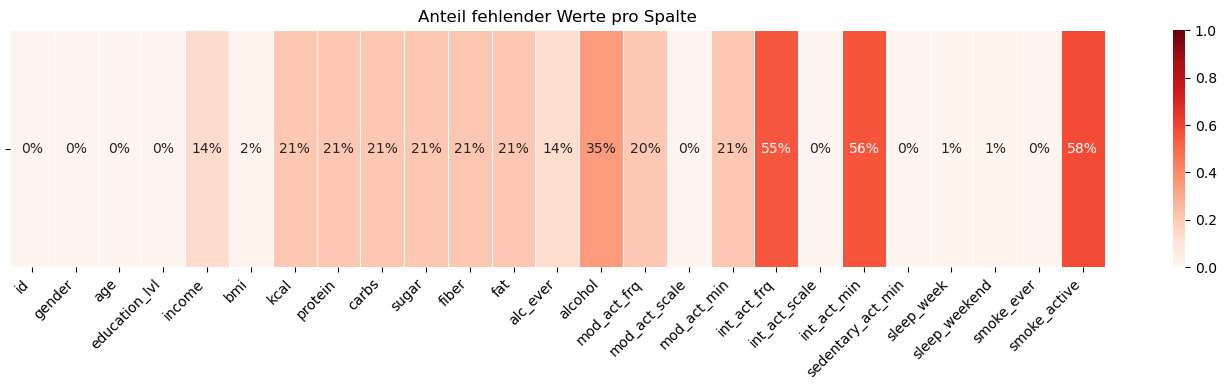

In [449]:
# Fehlende Werte zählen
missing = df_clean.isnull().sum()

# Prozentsatz fehlender Werte berechnen
missing_pct = (missing / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Spalte': missing.index,
    'Fehlend': missing.values,
    'Prozent': missing_pct.values
})
missing_df = missing_df[missing_df['Fehlend'] > 0]
display(missing_df)

# Optional: Visualisierung mit Heatmap – Anteil fehlender Werte pro Spalte
fig, ax = plt.subplots(figsize=(14, 4))
missing_matrix = df_clean.isnull().mean().to_frame().T  # Anteil als 0.0–1.0
sns.heatmap(
    missing_matrix,
    annot=True,
    fmt=".0%",
    cmap="Reds",         # Rot = viele fehlende Werte
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Anteil fehlender Werte pro Spalte")
ax.set_yticklabels([])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


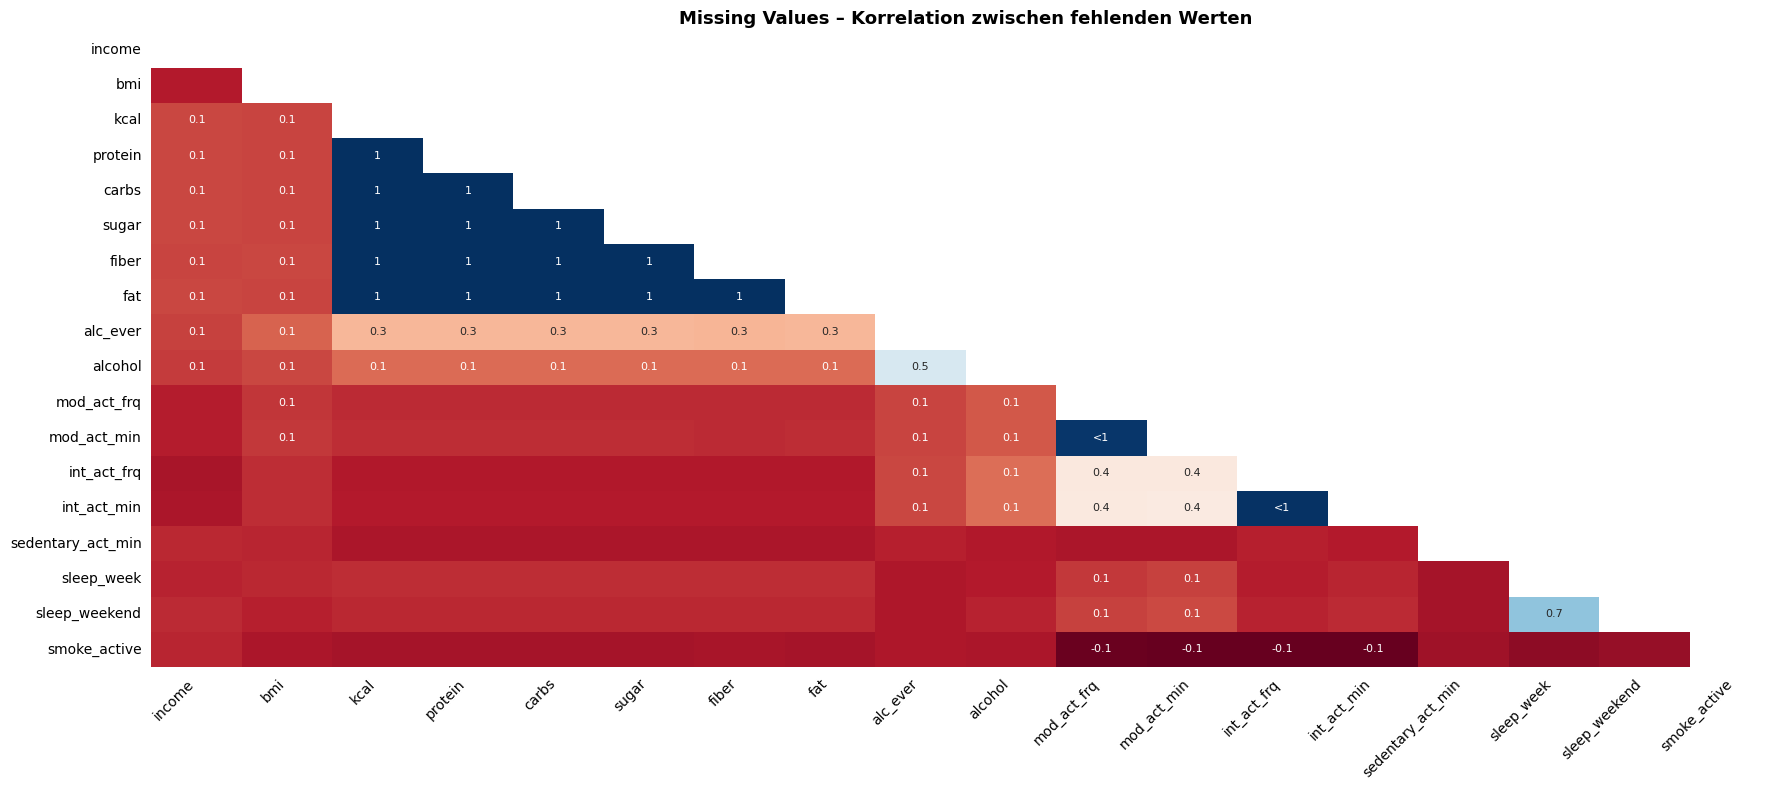

In [450]:
# Heatmap: Korrelation zwischen fehlenden Werten
msno.heatmap(df_clean, fontsize=10, figsize=(18, 8))
plt.title("Missing Values – Korrelation zwischen fehlenden Werten", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Es fällt auf, dass besonders in der Spalte zum aktiven Rauchen ("smoke_active") viele Werte fehlen (ca. 58%). Dies liegt aber daran, dass nur solche Probanden dazu befragt wurden, die bei einer vorherigen Fragen (in meinen Daten als "smoke_ever" benannt) angegeben hatten, dass sie in ihrem Leben mehr als 100 Zigaretten geraucht hatten. Bei "no / refuse / don't know" wurde die zweite Frage ("smoke_active") übersprungen.

Auch bei der Angabe der Minuten, für die eine physische Aktivität ausgeführt wird, fehlen 21% bzw. 56% der Werte. Dies liegt vermutlich daran, dass Probanden, die bereits bei der Frequenz einer physikalischer Aktivität "never / refused / don't know / not able to do" angegeben haben, die Fragen zur Dauer nicht gestellt bekommen. Viele Teilnehmer führen möglicherweise außerdem keine intensive physische Aktivität aus, was vielleicht die vielen fehlenden Werte bei der Frequenz dort erklärt.

Auch beim Alkohol fehlen 35% der Werte, dies könnte daran liegen, dass, falls "alc_ever" (jemals getrunken) verneint wurde, die folgende Frage nach der Menge ("alcohol") nicht mehr gestellt wurde.

---
## 4. Fehlende Werte behandeln

**Aufgabe:** Entscheiden Sie für jede Spalte mit fehlenden Werten, wie Sie damit umgehen.

**Mögliche Strategien:**
- Zeilen löschen (bei wenigen fehlenden Werten)
- Spalten löschen (bei sehr vielen fehlenden Werten)
- Fehlende Werte imputieren:
  - Numerische Spalten: Median oder Mittelwert
  - Kategoriale Spalten: Modus oder neue Kategorie

**Dokumentieren Sie Ihre Entscheidungen!**

### Dokumentation der Entscheidungen

- **BMI:** Bei der Zielvariablen können keine fehlenden Werte zugelassen werden, betroffene Zeilen müssen gelöscht werden. Da es sich um nur 2% der Daten handelt, ist das vertretbar.
- **Kalorienaufnahme, Makronährstoffe**: Hier habe ich überprüft, ob die fehlenden Werte jeweils in den gleichen Zeilen fehlen. Dies ist der Fall (siehe auch Heatmap), abgesehen von 7 Zeilen, in denen nur fiber fehlt. Eventuell könnte das daran liegen, dass an diesem Tag keine Ballaststoffe gegessen wurden, das ist aber eine Annahme und kann nicht überprüft werden. Da das Ernährungsverhalten bekanntermaßen eng mit Adipositas zusammenhängt, habe ich mich entschieden den Datenverlust von knapp 21% hier zu tolerieren.

In [451]:
# Überlappungsanalyse: NaN bei Nährstoffen
nutr_cols = ["kcal", "protein", "carbs", "sugar", "fiber", "fat"]

# Maske: mindestens eine Nährstoff-Spalte ist NaN
any_nutr_nan = df_clean[nutr_cols].isnull().any(axis=1)

# Maske: alle Nährstoff-Spalten sind NaN
all_nutr_nan = df_clean[nutr_cols].isnull().all(axis=1)

print(f"Zeilen mit mind. 1 NaN in Nährstoffen:  {any_nutr_nan.sum()}")
print(f"Zeilen mit NaN in ALLEN Nährstoffen:    {all_nutr_nan.sum()}")
print()

# Detailblick: wie viele NaN pro Spalte in den betroffenen Zeilen?
print("NaN-Zählungen pro Nährstoff-Spalte (gesamt):")
print(df_clean[nutr_cols].isnull().sum())
print()

# Gibt es Zeilen, wo z.B. kcal NaN ist, aber protein nicht?
partial_nan = any_nutr_nan & ~all_nutr_nan
print(f"Zeilen mit TEILWEISE fehlenden Nährstoffen: {partial_nan.sum()}")
if partial_nan.sum() > 0:
    print(df_clean.loc[partial_nan, nutr_cols].isnull().sum())

Zeilen mit mind. 1 NaN in Nährstoffen:  1272
Zeilen mit NaN in ALLEN Nährstoffen:    1265

NaN-Zählungen pro Nährstoff-Spalte (gesamt):
kcal       1265
protein    1265
carbs      1265
sugar      1265
fiber      1272
fat        1265
dtype: int64

Zeilen mit TEILWEISE fehlenden Nährstoffen: 7
kcal       0
protein    0
carbs      0
sugar      0
fiber      7
fat        0
dtype: int64


In [452]:
# Strategie 1: Zeilen mit fehlenden Werten löschen (falls anwendbar)
df_clean = df_clean.dropna(subset=["bmi", "kcal", "protein", "carbs", "sugar", "fiber", "fat"])
print("Restliche Zeilen nach droppen BMI und Nährstoffe:")
print(f"{df_clean.shape[0]} Zeilen (- {round((6023 - df_clean.shape[0]) / 6023 * 100)}%)")

Restliche Zeilen nach droppen BMI und Nährstoffe:
4702 Zeilen (- 22%)


- **Alkohol:** bei Probanden, die bei "alcohol_ever" 0 angegeben hatten (also nie getrunken haben), habe ich "alcohol" auf 0 (nie) gesetzt.

In [453]:
# Alkohol
# Wer alc_ever == 2 (No) hat, hat nie getrunken --> alcohol = 0
df_clean.loc[df_clean["alc_ever"] == 2, "alcohol"] = 0
# acl_ever selbst wird danach nicht mehr benötigt
df_clean = df_clean.drop(columns=["alc_ever"])
                         
print("Anzahl NaN alcohol: ", df_clean["alcohol"].isna().sum())
print("Anzahl refused/don't know alcohol: ", df_clean["alcohol"].isin([77.0, 99.0]).sum())

Anzahl NaN alcohol:  1106
Anzahl refused/don't know alcohol:  2


Es fehlen also in ca. 23,56% (1108/4702 = 0,2356) der Zeilen Angaben zum Alkohol. Das ist ein relativ großer Teil der Daten. Aber Alkohol hat allein durch seinen Kaloriengehalt vermutlich einen nicht zu vernachlässigenden Einfluss auf Adipositas. Deshalb möchte ich die Spalte über Alkohol nicht komplett droppen. Ich habe auch überlegt die Zeilen mit dem Median zu imputieren, dann würde aber eine Kategorie sehr überladen sein. Deshalb habe ich mich schließlich entschieden den Verlust von 23,56% der Daten doch in Kauf zu nehmen und die Zeilen mit fehlenden Angaben zum Alkohol zu droppen.

In [454]:
df_clean["alcohol"] = df_clean["alcohol"].replace([77.0, 99.0], np.nan)
df_clean = df_clean.dropna(subset=["alcohol"])
print(f"Restliche Zeilen nach droppen BMI, Nährstoffe, Alkohol: {df_clean.shape[0]} Zeilen (kumulativ - {round((6023 - df_clean.shape[0]) / 6023 * 100)}%)")

Restliche Zeilen nach droppen BMI, Nährstoffe, Alkohol: 3594 Zeilen (kumulativ - 40%)


In [455]:
# Strategie 2: Spalten mit zu vielen fehlenden Werten löschen
# Dies kam bei den vorliegenden Daten nicht infrage

- **körperliche Aktivität:** Haben alle, bei denen die Aktivitätsminuten fehlen, auch keine Aktivitätsfrequenz angegeben? Folgende Untersuchung zeigt, dass dies bei den meisten Probanden zutrifft (928), nur wenige (8) haben eine Frequenz angegeben.

In [456]:
# "refused" (7777) / "don't know" (9999) werden auf NaN gesetzt
df_clean["mod_act_frq"] = df_clean["mod_act_frq"].replace([7777.0, 9999.0], np.nan)

# Haben alle, bei denen mod_act_min fehlt auch mod_act_frq == 0?
fehlend = df_clean[df_clean["mod_act_min"].isin([7777.0, 9999.0]) | df_clean["mod_act_min"].isna()]
print("mod_act_frq bei Zeilen, in denen mod_act_min fehlt:")
print(fehlend["mod_act_frq"].value_counts(dropna=False))
print()

mod_act_frq bei Zeilen, in denen mod_act_min fehlt:
mod_act_frq
NaN    645
1.0      2
6.0      1
7.0      1
2.0      1
4.0      1
Name: count, dtype: int64



Die wenigen Zeilen, bei denen die Frequenz nicht fehlt, möchte ich auf den Median der Minuten setzen. Es ist nämlich scheinbar ja eine Aktivität erfolgt, es wurde nur keine Dauer angegeben. Es existieren dabei keine Zeilen, wo für die Frequenz 0 angegeben wurde (also nie eine Aktivität ausgeführt wird), sodass dieser Fall nicht behandelt werden muss.

In [457]:
median_mod = df_clean["mod_act_min"].median()
df_clean.loc[df_clean["mod_act_frq"].notna() & df_clean["mod_act_min"].isna(), "mod_act_min"] = median_mod

Meistens fehlt also auch mod_act_frq, wenn mod_act_min fehlt. Würden wir wieder alle Zeilen droppen, wo die körperliche Aktivität fehlt, verlieren wir erneut ca. 18% (645/3594 = 0,1795) der Daten. Da vermutlich aber die körperliche Aktivität eng mit Adipositas zusammenhängt, habe ich mich erneut entschieden das zu tolerieren. Deshalb droppe ich die NaN bei "mod_act_frq", wodurch dann auch bei "mod_act_min" keine mehr übrig sein dürften.

In [458]:
df_clean = df_clean.dropna(subset=["mod_act_frq"])
print(f"Restliche Zeilen nach droppen BMI, Nährstoffe, Alkohol, moderate Frequenz: {df_clean.shape[0]} Zeilen (kumulativ - {round((6023 - df_clean.shape[0]) / 6023 * 100)}%)")
print("Restliche NaN bei mod_act_min: ", df_clean["mod_act_min"].isna().sum())

Restliche Zeilen nach droppen BMI, Nährstoffe, Alkohol, moderate Frequenz: 2949 Zeilen (kumulativ - 51%)
Restliche NaN bei mod_act_min:  0


Jetzt machen wir die gleiche Überprüfung nochmal für intensive körperliche Aktivität.

In [459]:
# "refused" (7777) / "don't know" (9999) werden auf NaN gesetzt
df_clean["int_act_frq"] = df_clean["int_act_frq"].replace([7777.0, 9999.0], np.nan)

# Haben alle, bei denen mod_act_min fehlt auch mod_act_frq == 0?
fehlend = df_clean[df_clean["int_act_min"].isin([7777.0, 9999.0]) | df_clean["int_act_min"].isna()]
print("int_act_frq bei Zeilen, in denen int_act_min fehlt:")
print(fehlend["int_act_frq"].value_counts(dropna=False))
print()

int_act_frq bei Zeilen, in denen int_act_min fehlt:
int_act_frq
NaN    1271
1.0       1
2.0       1
4.0       1
5.0       1
Name: count, dtype: int64



Erneut setzen der "int_act_min" auf Median, wenn "int_act_frq" angegeben war.

In [460]:
median_int = df_clean["int_act_min"].median()
df_clean.loc[df_clean["int_act_frq"].notna() & df_clean["int_act_min"].isna(), "int_act_min"] = median_int

Wenn wir jetzt konsistenz zu "mod_act_frq" alle Zeilen droppen, bei denen "int_act_frq" fehlt, verlieren wir nochmal ca. 43% (1271/2949 = 0,4310) der Daten. Das ist erneut eine große Menge, ich habe mich aber aus den bereits oben für "mod_act_frq" genannten Gründen erneut dazu entschieden die Zeilen mit fehlenden Angaben zur "int_act_frq" zu droppen. Hiernach dürften auch wieder keine NaN mehr bei "int_act_min" mehr übrig sein.

In [461]:
df_clean = df_clean.dropna(subset=["int_act_frq"])
print("Restliche Zeilen nach droppen BMI, Nährstoffe, Alkohol, Sport Frequenzen:") 
print(f"{df_clean.shape[0]} Zeilen (kumulativ - {round((6023 - df_clean.shape[0]) / 6023 * 100)}%)")
print("Restliche NaN bei int_act_min: ", df_clean["int_act_min"].isna().sum())

Restliche Zeilen nach droppen BMI, Nährstoffe, Alkohol, Sport Frequenzen:
1678 Zeilen (kumulativ - 72%)
Restliche NaN bei int_act_min:  0


- **Einkommen, körperliche Inaktivität, Schlaf unter der Woche und am Wochenende:** Hier ergibt es Sinn den Median einzufügen, da es sich um numerische Werte handelt, jeweils nur eine recht geringe Anzahl an Werten fehlt (<14%) und somit die Vergabe des Medians keine starke Verfälschung erwarten lässt.

In [462]:
# Strategie 3: Numerische Werte imputieren
df_clean["income"] = df_clean["income"].fillna(df_clean["income"].median())

# 7777 == refused, 9999 == don't know müssen auch behandelt werden
df_clean["sedentary_act_min"] = df_clean["sedentary_act_min"].replace([7777.0, 9999.0], np.nan)
df_clean["sedentary_act_min"] = df_clean["sedentary_act_min"].fillna(df_clean["sedentary_act_min"].median())

df_clean["sleep_week"] = df_clean["sleep_week"].fillna(df_clean["sleep_week"].median())
df_clean["sleep_weekend"] = df_clean["sleep_weekend"].fillna(df_clean["sleep_weekend"].median())

- **Bildung:** taucht zwar bei den fehlenden Werten nicht auf, aber 7 steht hier auch für "refused" und 9 für "don't know", diese müssten behandelt werden. Da in meinem Datensatz aber keine solchen Fälle vorkommen, muss nicht gehandelt werden.

- **Rauchen:** Wie oben bereits erwähnt gab es hierzu zwei relevante Interviewfragen. In der Spalte "smoke_ever" wird gefragt ob Probanden in ihrem Leben > 100 Zigaretten geraucht haben, bei "smoke_active" wird dann gefragt, ob sie aktuell noch rauchen (nur wenn vorher ja angegeben wurde). Ich habe die Spalten zusammengefasst und in Nie-Raucher, Ex-Raucher und Raucher eingeteilt.

In [463]:
# Strategie 4: Kategoriale Werte imputieren                                                         
# Erschaffung einer neuen Kategorie für das Rauchen
def raucher_status(row):
    smoke_ever   = row["smoke_ever"]    # 1=Ja (>100 im Leben), 2=Nein, 7=Refused, 9=Don't know
    smoke_active = row["smoke_active"]  # 1=täglich, 2=manchmal, 3=gar nicht, 7=Refused, 9=Don't know

    if smoke_ever in [7, 9]:
        return np.nan  # refused / don't know
    elif smoke_ever == 2:
        return 0  # Nie-Raucher
    elif smoke_active in [7, 9]:
        return np.nan  # refused / don't know
    elif smoke_active == 1:
        return 2  # Aktueller Raucher (täglich)
    elif smoke_active == 2:
        return 2  # Aktueller Raucher (manchmal)
    elif smoke_active == 3:
        return 1  # Ex-Raucher
    else:
        return np.nan  # Wirklich fehlend

df_clean["smoke_status"] = df_clean.apply(raucher_status, axis=1)
print(df_clean["smoke_status"].value_counts(dropna=False))

smoke_status
0.0    1120
1.0     385
2.0     172
NaN       1
Name: count, dtype: int64


In [464]:
# es bleibt nur 1 NaN übrig, diese geringe Anzahl kann gedroppt werden
df_clean = df_clean.dropna(subset=["smoke_status"])
df_clean = df_clean.drop(columns=["smoke_ever", "smoke_active"]) # alte Zeilen droppen

In [465]:
# Überprüfung: Sind alle fehlenden Werte behandelt?
print(df_clean.shape)
print(df_clean.isnull().sum())

(1677, 23)
id                   0
gender               0
age                  0
education_lvl        0
income               0
bmi                  0
kcal                 0
protein              0
carbs                0
sugar                0
fiber                0
fat                  0
alcohol              0
mod_act_frq          0
mod_act_scale        0
mod_act_min          0
int_act_frq          0
int_act_scale        0
int_act_min          0
sedentary_act_min    0
sleep_week           0
sleep_weekend        0
smoke_status         0
dtype: int64


---
## 5. Duplikate identifizieren und entfernen

**Aufgabe:** Prüfen Sie, ob Ihr Datensatz doppelte Zeilen enthält.

**Was Sie tun sollten:**
- Zählen Sie die Anzahl doppelter Zeilen
- Entfernen Sie Duplikate (falls vorhanden)
- Überprüfen Sie die neue Anzahl der Zeilen

In [466]:
# Anzahl doppelter Zeilen
dups = df_clean.duplicated(subset=['id']).sum()
print(f"Duplikate: {dups}")

# Duplikate entfernen
df_clean.drop_duplicates(subset=['id'], inplace=True)

# Neue Dimensionen prüfen
print(f"Nach Entfernung: {df_clean.shape[0]} Zeilen")

Duplikate: 0
Nach Entfernung: 1677 Zeilen


---
## 6. Datentypen überprüfen und anpassen

**Aufgabe:** Stellen Sie sicher, dass alle Spalten die richtigen Datentypen haben.

**Was Sie prüfen sollten:**
- Sind numerische Spalten als `int` oder `float` kodiert?
- Sind kategoriale Spalten als `object` oder `category` kodiert?
- Müssen Datentypen konvertiert werden?

In [467]:
# Datentypen anzeigen
print(df_clean.dtypes)
print()

id                   float64
gender               float64
age                  float64
education_lvl        float64
income               float64
bmi                  float64
kcal                 float64
protein              float64
carbs                float64
sugar                float64
fiber                float64
fat                  float64
alcohol              float64
mod_act_frq          float64
mod_act_scale            str
mod_act_min          float64
int_act_frq          float64
int_act_scale            str
int_act_min          float64
sedentary_act_min    float64
sleep_week           float64
sleep_weekend        float64
smoke_status         float64
dtype: object



In [468]:
# Datentypen konvertieren
# Integer-Spalten
int_spalten = ["id", "age", "alcohol"]
for col in int_spalten:
    df_clean[col] = df_clean[col].astype(int)
for col in ["mod_act_min", "int_act_min", "sedentary_act_min"]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print(df_clean[["mod_act_min", "int_act_min", "sedentary_act_min"]].dtypes)

# Kategoriale Spalten
cat_spalten = ["gender", "education_lvl", "mod_act_scale", "int_act_scale", "smoke_status"]
for col in cat_spalten:
    df_clean[col] = df_clean[col].astype("category")
print("Neue Datentypen:")
print(df_clean.dtypes)

mod_act_min          float64
int_act_min          float64
sedentary_act_min    float64
dtype: object
Neue Datentypen:
id                      int64
gender               category
age                     int64
education_lvl        category
income                float64
bmi                   float64
kcal                  float64
protein               float64
carbs                 float64
sugar                 float64
fiber                 float64
fat                   float64
alcohol                 int64
mod_act_frq           float64
mod_act_scale        category
mod_act_min           float64
int_act_frq           float64
int_act_scale        category
int_act_min           float64
sedentary_act_min     float64
sleep_week            float64
sleep_weekend         float64
smoke_status         category
dtype: object


---
## 7. Ausreißer identifizieren

**Aufgabe:** Identifizieren Sie Ausreißer in numerischen Spalten.

**Methoden:**
- Visualisierung mit Boxplots
- IQR-Methode (Interquartile Range)
- Statistische Analyse (describe)

**Wichtig:** Entscheiden Sie für jeden Ausreißer, ob er:
- Ein Fehler ist (→ entfernen oder korrigieren)
- Ein echter extremer Wert ist (→ behalten)

In [469]:
# Numerische Spalten auswählen
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "id"]

# Statistische Übersicht
print(df_clean[numeric_cols].describe())

               age       income          bmi          kcal      protein  \
count  1677.000000  1677.000000  1677.000000   1677.000000  1677.000000   
mean     49.202743     3.580501    28.614967   2091.458557    81.074484   
std      16.919560     1.504282     6.588656    902.856953    41.718437   
min      20.000000     0.020000    14.900000    249.000000     5.890000   
25%      34.000000     2.330000    24.200000   1468.000000    53.410000   
50%      50.000000     4.060000    27.400000   1958.000000    73.710000   
75%      64.000000     5.000000    31.700000   2547.000000    99.960000   
max      80.000000     5.000000    69.100000  10446.000000   459.150000   

             carbs        sugar        fiber          fat      alcohol  \
count  1677.000000  1677.000000  1677.000000  1677.000000  1677.000000   
mean    228.713673    93.500966    17.815146    88.314866     5.163387   
std     109.811596    61.619665    10.972852    46.490560     2.840555   
min       3.490000     0.750

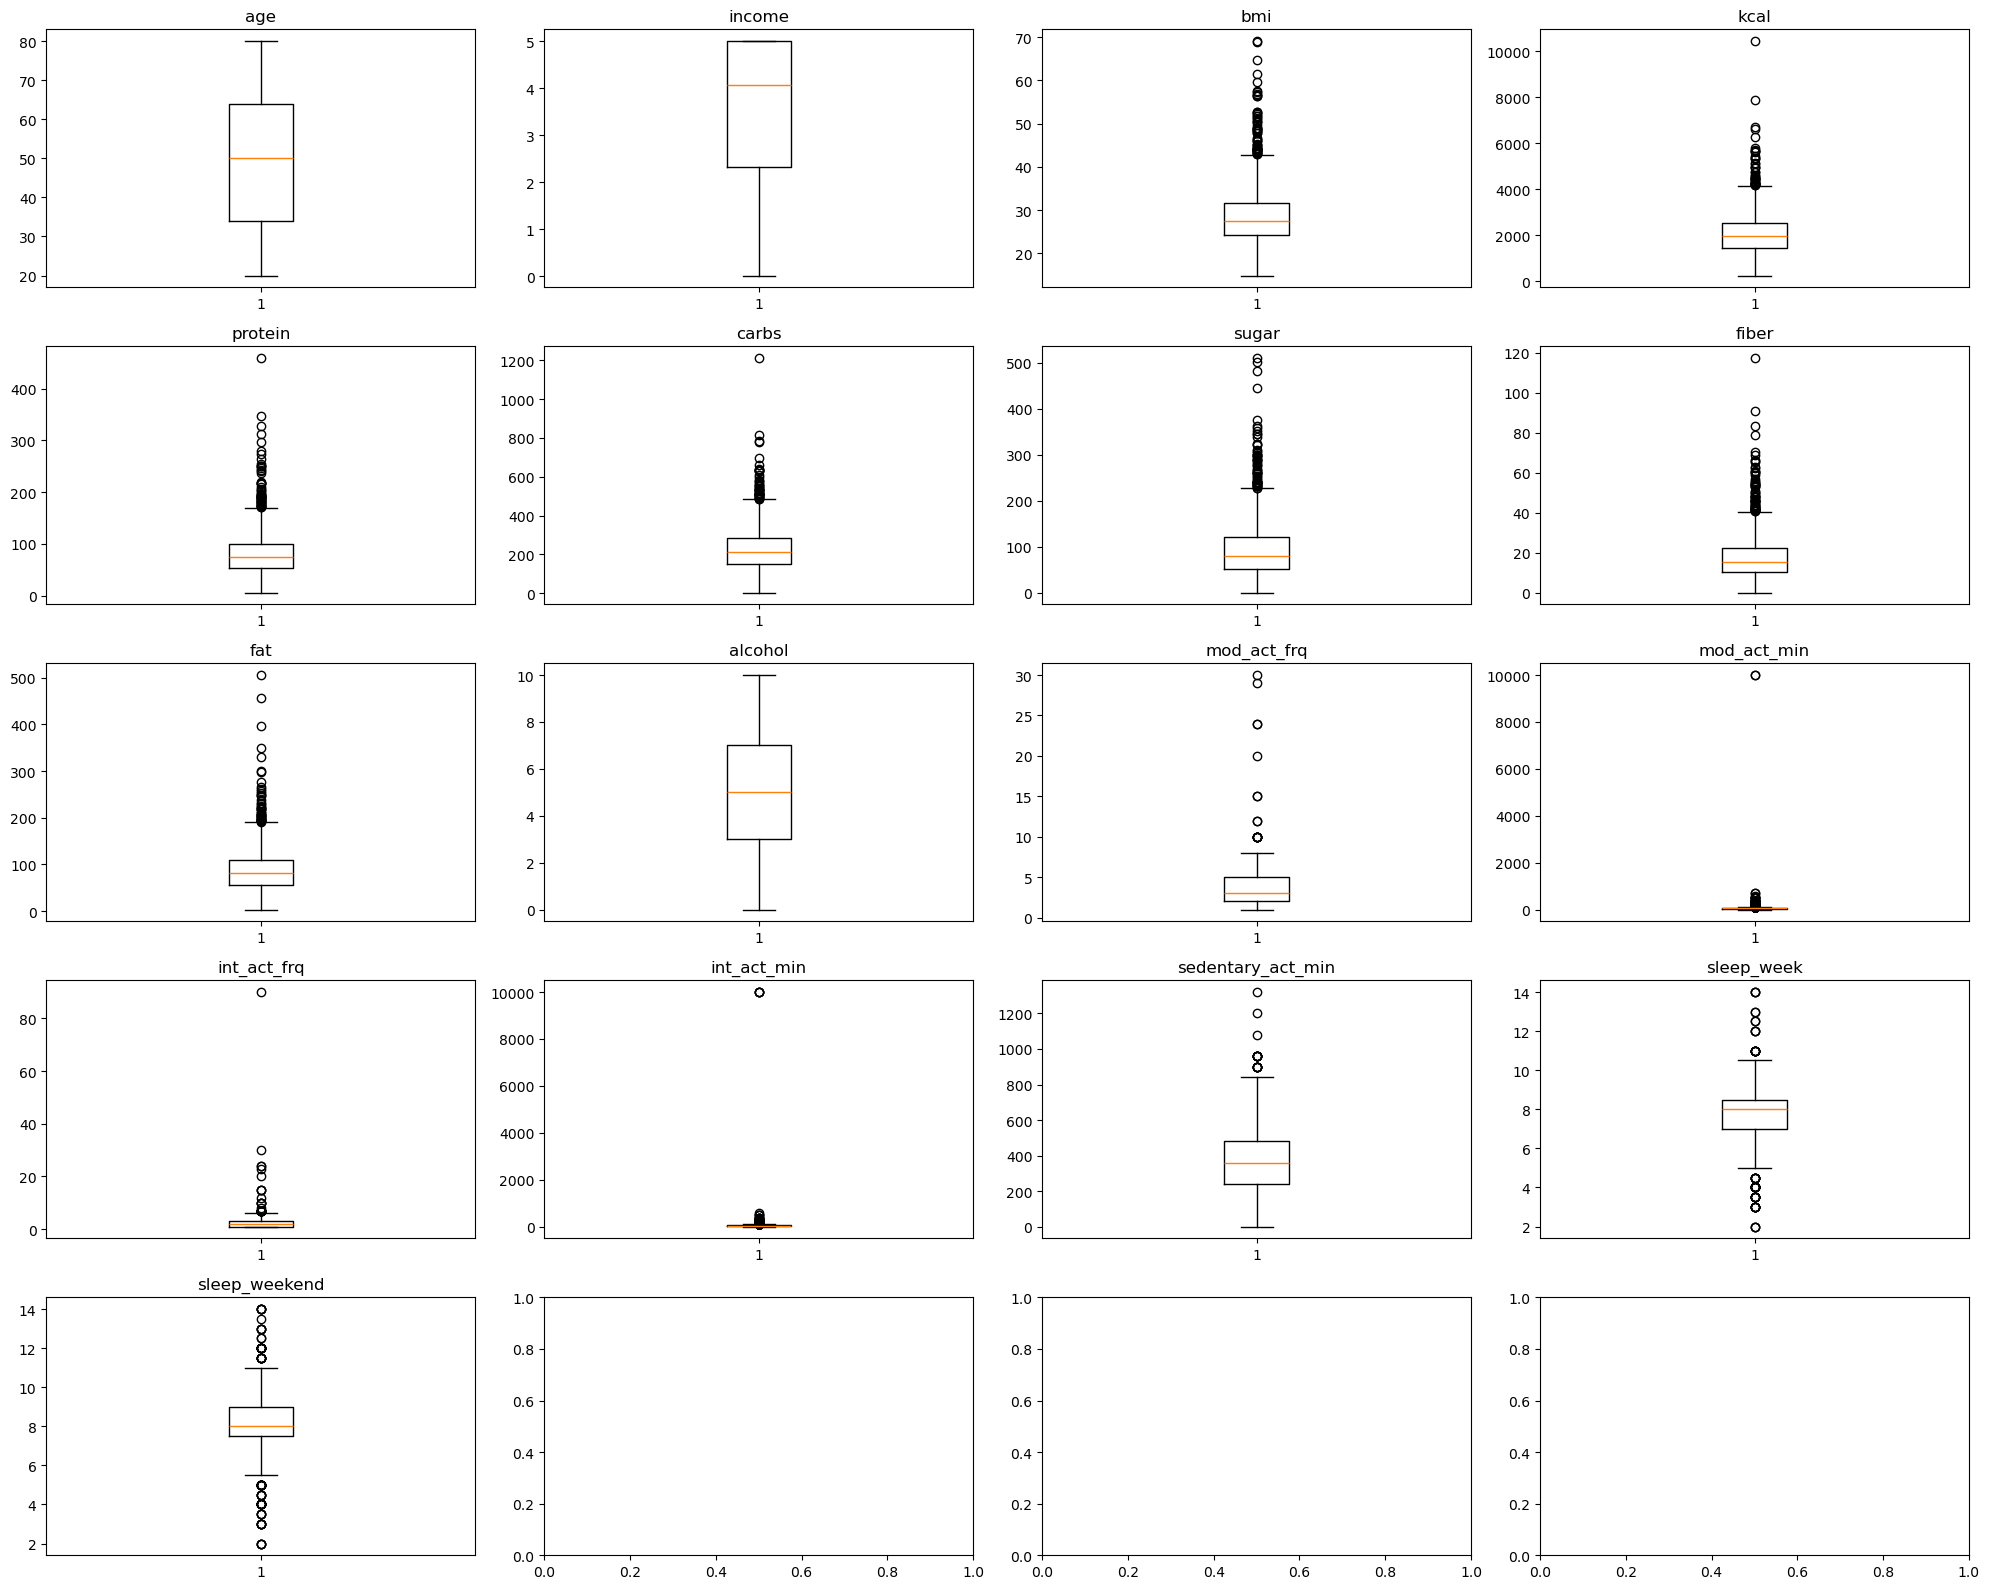

In [471]:
# Boxplots
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

- **age:** keine Ausreißer (alles unter 20 Jahren wurde ja schon rausgefiltert, beim Design des Fragebogens wurde festgelegt alle Werte über 80 Jahre auf 80 festzulegen)
- **income:** Werte von 0 - 5 können laut Dokumentation vorkommen, alles über 5 wird auf 5 festgelegt. Also keine Ausreißer.
- **bmi:** ein Minimum von 11 scheint medizinisch sehr fraglich plausibel zu sein. Für die Forschungsfrage ist es außerdem sinnvoll Untergewichtige herauszufiltern. Die Ausreißer nach oben würde ich beibehalten, da ein BMI von max. 69,9 zwar selten, aber möglich ist.
- **kcal**: hier erscheint ein Maximum von fast 460g sehr viel. Eine Überprüfung der korrespondierenden kcal scheint aber konstistent zu sein, also habe ich mich entschieden die Ausreißer beizubehalten.
- **carbs**: Die Person mit den hohen Kohlenhydraten ist dieselbe mit den hohen Kalorien, das scheint konsistent zu sein, weshalb ist das behalten habe.
- **sugar, fiber**: Untermengen von carbs, also gleiches Vorgehen.
- **fat**: gleiches Vorgehen wie bei carbs, da der höchste Ausreißer wie vorher geprüft auch zu der Person mit den vielen kcal gehört.
- **Daten zu physikalischer Aktivität**: Feature Engineering sinnvoll (s.u.), da es noch verschiedene Einheiten gibt und somit Ausreißer nicht beurteilt werden können. Bei "mod_act_min" und "int_act_min" gibt es noch als Wert 9999, was für "don't know" steht uns somit noch mit Median gefüllt werden muss (analog zu Vorgehen bei der Behandlung von fehlenden Werten)
- **sedentary activity**: Nur eine Minute pro Tag erscheint unplausibel. Das Maximum ist zwar unwahrscheinlich, kann aber bei jemandem mit einem Schreibtischjob, der sehr wenig schläft, vorkommen (Schlafenszeit sollte nicht mit angegeben werden).
- **sleep**: Zwar sind 2 bzw. 14h Schlaf selten, aber plausibel.

In [472]:
# hohe Proteinwerte checken
print(df_clean["protein"].quantile([0.95, 0.99, 0.999]))
print()
print(df_clean[df_clean["protein"] > 300][["kcal", "protein", "carbs", "fat"]])
print()

# hohe Carbs checken
print(df_clean["carbs"].quantile([0.95, 0.99, 0.999]))
print()
print(df_clean[df_clean["carbs"] > 800][["kcal", "protein", "carbs", "fat"]])

0.950    157.12200
0.990    218.48320
0.999    334.60456
Name: protein, dtype: float64

        kcal  protein   carbs     fat
182   4458.0   311.62  352.28  198.87
268   6723.0   347.07  486.15  395.76
4723  5349.0   328.63  634.54  171.86
4862  3578.0   459.15  186.94   97.87

0.950    422.04200
0.990    564.28320
0.999    792.93764
Name: carbs, dtype: float64

         kcal  protein    carbs     fat
3033   5650.0   183.92   813.63  199.39
4448  10446.0   264.30  1210.93  505.62


---
## 8. Ausreißer behandeln

**Aufgabe:** Behandeln Sie die identifizierten Ausreißer entsprechend Ihrer Analyse.

**Mögliche Strategien:**
- Ausreißer entfernen (wenn sie Fehler sind)
- Ausreißer behalten (wenn sie valide sind)
- Ausreißer begrenzen (Capping/Flooring)

**Dokumentieren Sie Ihre Entscheidungen!**

In [473]:
# Ausreißer entfernen: Capping
print("Anzahl Untergewichtiger: ", (df_clean["bmi"] < 18.5).sum())
df_clean = df_clean[df_clean["bmi"] >= 18.5]
print("Restliche Zeilen nach droppen BMI, Nährstoffe, Alkohol, Sport Frequenzen und Entfernen Untergewichtiger:")
print(f"{df_clean.shape[0]} Zeilen (kumulativ - {round((6023 - df_clean.shape[0]) / 6023 * 100)}%)")
print()

# Aktivitätsminuten "don't know" mit Median ersetzen
df_clean["mod_act_min"] = df_clean["mod_act_min"].replace([7777.0, 9999.0], median_mod)
df_clean["int_act_min"] = df_clean["int_act_min"].replace([7777.0, 9999.0], median_int)

# Sedentary activity: unteren Cut off finden
print("Quantile sedentary activity:")
print(df_clean["sedentary_act_min"].quantile([0.001, 0.01, 0.05]))
print(df_clean[df_clean["sedentary_act_min"] < 30][["sedentary_act_min"]].value_counts())
df_clean = df_clean[df_clean["sedentary_act_min"] >= 30]

Anzahl Untergewichtiger:  15
Restliche Zeilen nach droppen BMI, Nährstoffe, Alkohol, Sport Frequenzen und Entfernen Untergewichtiger:
1662 Zeilen (kumulativ - 72%)

Quantile sedentary activity:
0.001      3.983
0.010     60.000
0.050    120.000
Name: sedentary_act_min, dtype: float64
sedentary_act_min
15.0                 2
6.0                  2
7.0                  1
25.0                 1
1.0                  1
5.0                  1
2.0                  1
Name: count, dtype: int64


---
## 9. Feature Engineering

Bei der Behandlung von fehlenden Werten ist schon Feature Engineering zum Rauchen erfolgt.

**physische Aktivität:** Die Werte lagen nicht in einer einheitlichen Skala vor, sondern in Einheiten pro Tag/Woche/Monat/Jahr. Zusätzlich wurde die durschnittliche Dauer angegeben. Als neue Kategorie habe ich diese Angaben in den MET-Minuten-Score umgerechnet und gemäß den Empfehlungen der WHO in Kategorien eingeteilt.

In [474]:
# Erschaffung einer neuen Kategorie für physische Aktivität

# Schritt 1: Häufigkeit auf "pro Woche" normalisieren
einheit_zu_wochen = {"D": 7, "W": 1, "M": 1/4.33, "Y": 1/52}

def zu_pro_woche(frequenz, einheit):
    if pd.isna(frequenz) or pd.isna(einheit):
        return np.nan
    if frequenz in [7777, 9999]:  # refused / don't know
        return np.nan
    faktor = einheit_zu_wochen.get(einheit, np.nan)
    return frequenz * faktor

df_clean["mod_freq_week"] = df_clean.apply(lambda r: zu_pro_woche(r["mod_act_frq"], r["mod_act_scale"]), axis=1)
df_clean["int_freq_week"] = df_clean.apply(lambda r: zu_pro_woche(r["int_act_frq"], r["int_act_scale"]), axis=1)

# Schritt 2: Minuten pro Woche berechnen
df_clean["mod_min_week"] = df_clean["mod_freq_week"] * df_clean["mod_act_min"]
df_clean["int_min_week"] = df_clean["int_freq_week"] * df_clean["int_act_min"]

# Schritt 3: MET-Minuten/Woche — NaN als 0 behandeln, damit ein fehlender
# Wert nicht den gesamten Score zunichte macht
df_clean["MET_min_week"] = (
    df_clean["mod_min_week"].fillna(0) * 4 +
    df_clean["int_min_week"].fillna(0) * 8
)

# Schritt 4: Kategorisierung nach WHO-Empfehlung
# < 600       = inaktiv
# 600–3000    = moderat aktiv
# > 3000      = sehr aktiv
def aktivitaet_kategorie(met):
    if pd.isna(met):
        return np.nan
    elif met < 600:
        return 0  # inaktiv
    elif met <= 3000:
        return 1  # moderat aktiv
    else:
        return 2  # sehr aktiv

df_clean["activity_level"] = df_clean["MET_min_week"].apply(aktivitaet_kategorie)
print(df_clean["activity_level"].value_counts(dropna=False))
print()

# Schritt 5: Hilfsspalten droppen, nur activity_level behalten
df_clean = df_clean.drop(columns=["mod_act_frq", "mod_act_scale", "mod_act_min",
                                   "int_act_frq",  "int_act_scale", "int_act_min",
                                   "mod_freq_week", "int_freq_week",
                                   "mod_min_week",  "int_min_week",  "MET_min_week"])

activity_level
1    1045
2     315
0     293
Name: count, dtype: int64



- **Alkohol**: Hier gibt es keine kontinuierliche Skala. 0 steht für "nie im letzten Jahr", 1 für "jeden Tag", 2 für "fast jeden Tag", steigende Variablenwerte stehen dann für sinkende Häufigkeit des Alkoholkonsums. Deshalb habe ich die Werte in fünf Kategorien eingeteilt und die Sortierung der Skala folgendermaßen angepasst:
  - 0 = nie
  - 1 = selten (1-2x bis 7-11x pro Jahr)
  - 2 = Moderat (einmal pro Monat bis einmal pro Woche)
  - 3 = Häufig (2x/Woche bis fast täglich)
  - 4 = (fast) täglich (fast täglich bis täglich)

In [475]:
print(df_clean["alcohol"].value_counts().sort_index())

alcohol
0     105
1      56
2     139
3     208
4     240
5     168
6     229
7     120
8      93
9     156
10    139
Name: count, dtype: int64


In [476]:
def alkohol_kategorie(val):
    if val == 0:
        return 0  # Never
    elif val >= 8:
        return 1  # Selten (1-2x bis 7-11x pro Jahr)
    elif val >= 5:
        return 2  # Moderat (Once a month bis Once a week)
    elif val >= 3:
        return 3  # Häufig (2x/Woche bis nearly every day)
    else:
        return 4  # (fast) Täglich (nearly every day bis every day)

df_clean["alcohol"] = df_clean["alcohol"].apply(alkohol_kategorie)
df_clean["alcohol"] = df_clean["alcohol"].astype("category")

print(df_clean["alcohol"].value_counts().sort_index())

alcohol
0    105
1    388
2    517
3    448
4    195
Name: count, dtype: int64


- **Schlaf:** aus Schlaf unter der Woche und am Wochenende habe ich den "Average Daily Sleep" errechnet.

In [477]:
df_clean["sleep_avg"] = (df_clean["sleep_week"] * 5 + df_clean["sleep_weekend"] * 2) / 7
df_clean["sleep_avg"] = df_clean["sleep_avg"].round(1)
df_clean = df_clean.drop(columns=["sleep_week", "sleep_weekend"])
df_clean["sleep_avg"].describe()

count    1653.00000
mean        7.79141
std         1.25316
min         2.00000
25%         7.10000
50%         8.00000
75%         8.50000
max        13.70000
Name: sleep_avg, dtype: float64

- **BMI:** Hier habe ich für das Machine Learning später drei Kategorien erstellt. Die Ursprüngliche Variable BMI muss anschließend gedroppt werden, damit es nicht zu einem Data Leakage kommt. Neue Kategorien nach Vorbild WHO:
  - 0 --> normal (BMI <25)
  - 1 --> übergewichtig (BMI 25 bis <30)
  - 2 --> adipös (BMI >= 30)

In [478]:
def bmi_kategorie(bmi):
    if bmi < 25:
        return 0  # Normal
    elif bmi < 30:
        return 1  # Übergewichtig
    else:
        return 2  # Adipös

df_clean["bmi_cat"] = df_clean["bmi"].apply(bmi_kategorie)
df_clean["bmi_cat"] = df_clean["bmi_cat"].astype("category")
df_clean = df_clean.drop(columns=["bmi"])

print(df_clean["bmi_cat"].value_counts().sort_index())

bmi_cat
0    502
1    594
2    557
Name: count, dtype: int64


---
## 10. Inkonsistenzen beheben

**Aufgabe:** Suchen Sie nach Inkonsistenzen in kategorialen Spalten.

**Was Sie prüfen sollten:**
- Unterschiedliche Schreibweisen (z.B. "ja", "Ja", "JA")
- Leerzeichen am Anfang oder Ende
- Tippfehler
- Unerwartete Kategorien

Außer der Kategorien bei der Skala der physischen Aktivität, sind alle kategorischen Variablen numerisch. Die Bytes wurden schon zu Beginn des Skriptes decodiert. Die physikalische Aktivität wurde im Feature Engineering schon behandelt. Somit sind die ersten drei Punkte in meinem Datensatz nicht relevant. Es gibt auch keine Spalten mehr mit dem Datentyp object.

In [479]:
# Kategoriale Spalten auswählen
categorical_cols = df_clean.select_dtypes(include="category").columns


# Einzigartige Werte pro kategorialer Spalte anzeigen
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


gender:
gender
1.0    847
2.0    806
Name: count, dtype: int64

education_lvl:
education_lvl
5.0    883
4.0    463
3.0    228
2.0     55
1.0     24
Name: count, dtype: int64

alcohol:
alcohol
2    517
3    448
1    388
4    195
0    105
Name: count, dtype: int64

smoke_status:
smoke_status
0.0    1104
1.0     380
2.0     169
Name: count, dtype: int64

bmi_cat:
bmi_cat
1    594
2    557
0    502
Name: count, dtype: int64


Wir sehen, dass hier keine unerwarteten Kategorien auftreten.

---
## 11. Finale Überprüfung

**Aufgabe:** Führen Sie eine finale Qualitätskontrolle durch.

**Checkliste:**
- ✓ Keine fehlenden Werte (oder bewusst belassen)
- ✓ Keine Duplikate
- ✓ Korrekte Datentypen
- ✓ Ausreißer behandelt
- ✓ Inkonsistenzen behoben
- ✓ Datensatz ist bereit für die Analyse

In [480]:
# Finale Übersicht
print(f"Finale Dimensionen: {df_clean.shape[0]} Zeilen, {df_clean.shape[1]} Spalten")
print("Vorherige Dimensionen: 6023 Zeilen, 25 Spalten")
print(f"Retention Rate: {round(df_clean.shape[0]/6023*100)}%")
print()

print("\nFehlende Werte:")
print(df_clean.isnull().sum())
print()

print("\nDatentypen:")
print(df_clean.dtypes)
print()

print("\nErste Zeilen des bereinigten Datensatzes:")
print(df_clean.head())


Finale Dimensionen: 1653 Zeilen, 17 Spalten
Vorherige Dimensionen: 6023 Zeilen, 25 Spalten
Retention Rate: 27%


Fehlende Werte:
id                   0
gender               0
age                  0
education_lvl        0
income               0
kcal                 0
protein              0
carbs                0
sugar                0
fiber                0
fat                  0
alcohol              0
sedentary_act_min    0
smoke_status         0
activity_level       0
sleep_avg            0
bmi_cat              0
dtype: int64


Datentypen:
id                      int64
gender               category
age                     int64
education_lvl        category
income                float64
kcal                  float64
protein               float64
carbs                 float64
sugar                 float64
fiber                 float64
fat                   float64
alcohol              category
sedentary_act_min     float64
smoke_status         category
activity_level          int64
sle

---
## 12. Bereinigten Datensatz speichern

**Aufgabe:** Speichern Sie Ihren bereinigten Datensatz als CSV-Datei.

**Wichtig:** Dieser bereinigte Datensatz wird in den kommenden Wochen für Visualisierung und Machine Learning verwendet!

In [481]:
# Bereinigten Datensatz speichern
df_clean.to_csv('obesity_cleaned.csv', index=False)

print("Bereinigter Datensatz wurde gespeichert!")

Bereinigter Datensatz wurde gespeichert!


---
## Reflexion

**Dokumentieren Sie Ihre Arbeit:**

Beantworten Sie folgende Fragen in einer Markdown-Zelle:

1. Welche Hauptprobleme hatte Ihr ursprünglicher Datensatz?
2. Welche Bereinigungsschritte waren am wichtigsten?
3. Wie viele Zeilen/Spalten haben Sie entfernt und warum?
4. Welche Herausforderungen gab es und wie haben Sie diese gelöst?
5. Ist Ihr Datensatz jetzt bereit für die Analyse?

### Ihre Reflexion:

1. **Hauptprobleme:**
   - Daten lagen nicht im csv, sondern im xpt Format vor
   - Daten lagen in vielen verschiedenen Tabellen mit sehr vielfältigen Spalten vor
   - zusätzlich zu fehlenden Werten gab es bei manchen Items noch "refused" oder "don't know"
   - für manche Spalten (Alkohol, Rauchen) mussten Infos aus mehreren Spalten zusammengeführt werden
   - Kombination aus Fragebogen und Untersuchungsergebnissen

2. **Wichtigste Schritte:**
   - Tabellen zusammenfügen
   - relevante Spalten aussuchen
   - "refused", "don't know" und NaN behandeln
   - Feature Engineering: MET-Score, Rauchen und Alkohol in Kategorien eingeteilt, Average Sleep

3. **Entfernte Daten:**
   - Probanden, die jünger als 20 Jahre alt waren
   - Schwangere
   - Probanden, die nur den Fragebogen beantwortet haben, aber nicht untersucht wurden
   - Untergewichtige
   - fehlende Angaben zu Kalorienaufnahme, Makronährstoffen oder Alkohol
   - insgesamt wurden 4370 Zeilen entfernt und die Spalten von 23 ursprünglich importierten auf 17 reduziert

4. **Herausforderungen:**
   - Der Datenimport und das Cleaning waren sehr zeitintensiv
   - Kategorien lagen in Byte Format vor
   - Ich bin unsicher, ob es sinnvoll ist sowohl die kcal, als auch die Makronärhstoffe zu behalten, da diese ja eng zusammenhängen. Da aber z.B. Alkohol auch zu den kcal beiträgt, habe ich mich entschieden kcal zu behalten. Gleiches gilt für Zucker und Ballaststoffe als Teil der Kohlenhydrate. Da diese aber evtl. Zusatzinfos geben können, da sie vermutlich unterschiedlich mit Adipositas korrelieren, habe ich das auch erstmal belassen.

5. **Bereitschaft für Analyse:**
   - Ja, es sind noch genug Zeilen vorhanden und die Daten wurden ausführlich gecleaned. Ob alle Features relevant sind, wird sich im weiteren Verlauf zeigen.